# Distributed Intelligence in the Computing Continuum

This tutorial describes a complete feedback cycle for an adaptive stream processing service that optimizes its performance throughout evolving requirements. The core phases of this cycle, following the traditional MAPE-K loop, are:

1. **Monitor**: Collect service telemetry
2. **Analyze**: Regression analysis of structural knowledge
3. **Plan**: Intent-based inference
4. **Execute**: Service scaling

Note that this abstract cycle can be implemented through various technologies and the ones presented in this tutorial present only one of many possibilities.

To reduce the experimental overhead of this tutorial, we do not actually run any physical services; instead, we operate on a prerecorded dataset that tracks the service behavior during runtime. Interested participants can find the complete experimental platform in this [repository](github.com/borissedlak/elastic-workbench).



## General Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('default')

from agent.components import RASK
from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType, theoretical_param_bounds, ServiceVar, FIG_SIZE_DEFAULT
from agent.components.commons import SloSet

services = [ServiceType.QR, ServiceType.CV, ServiceType.PC]
slos = [SloSet.DEFAULT, SloSet.HIGH_PERF, SloSet.LOW_COST, SloSet.HIGH_QUALITY]

## **Monitor**: Service Telemetry

In [ ]:
# TODO: Here I can just show the data structure

df_explore = pd.read_csv("../../statics/agent_experience/metrics_ICSOC_EXPLORE.csv")
df_explore_preprocessed = RASK.preprocess_data(df_explore)

## **Analyze**: Regression Analysis of Structural Knowledge

### Create Structural Knowledge

### Functional Data Analysis

In [ ]:
# import plotly.io as pio
#
# print(pio.renderers)
# pio.renderers.default = "chrome"
# import plotly
# import jupyterlab
#
# print(plotly.__version__)
# print(jupyterlab.__version__)

# for type in ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
#          'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
#          'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
#          'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
#          'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']:

In [ ]:
import plotly.io as pio
pio.renderers.default = 'browser'

gp_list = []
lml_history = []

data_splits = 100
tested_range = 20

for i in range(tested_range):
    gp_all_services = {}
    data_ratio = (i + 1) / data_splits
    lml_all_service = []

    for s in services:
        # Initialize and train GP model
        draw_figures = i == 0 or i == tested_range - 1
        _gp = GASK(s, create_figures=draw_figures, display_figures=draw_figures)
        _gp.init_model(df_explore, data_density=data_ratio)

        _lml = _gp.get_model_lml(s, "max_tp")
        lml_scaled = _lml / data_ratio
        lml_all_service.append(lml_scaled)
        # print(f"Ratio {data_ratio}: LML = {lml:.2f}")
        gp_all_services[s] = _gp

    lml_history.append(lml_all_service)
    gp_list.append(gp_all_services)

    print(f"Finished {i + 1} / {tested_range} of the Gaussian Processes")

lml_history = np.array(lml_history)


#### Create LML Figure

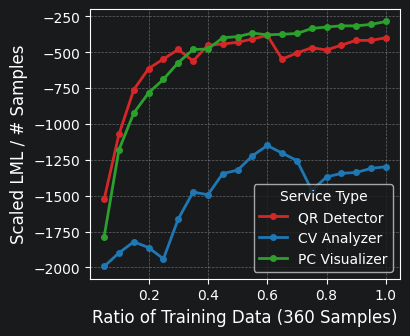

In [10]:
# 1. Define the X-axis (Data Ratios)
data_ratios = np.arange(1, tested_range + 1) / data_splits

# 2. Create the Figure
plt.figure(figsize=FIG_SIZE_DEFAULT)

# Service labels matching your 'services' list order
labels = ['QR Detector', 'CV Analyzer', 'PC Visualizer']
colors = ['#d62728', '#1f77b4', '#2ca02c']  # Red, Blue, Green

for i in range(lml_history.shape[1]):
    plt.plot(data_ratios * (data_splits / tested_range), lml_history[:, i],
             marker='o', markersize=4, linewidth=2,
             label=labels[i], color=colors[i])

# 3. Formatting
abs_samples = int(len(df_explore) * (tested_range / data_splits))
plt.xlabel(f'Ratio of Training Data ({int(abs_samples / 3)} Samples)', fontsize=12)
plt.ylabel('Scaled LML / # Samples', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Service Type")
plt.show()

In [ ]:

# plt.savefig('../../figures/E1/training/lml_convergence.pdf')

RUN_HEATMAP = False # TODO: Does the heatmap provide some benefit?
if RUN_HEATMAP:

    from agent.components.GaussianProcess import get_empirical_variable_bounds
    from utils import visualize_ndarray
    from agent.components.commons import ServiceVar
    from typing import Dict
    from agent.components.Optimizer import VersatileMapElites


    def extract_pfo_for_SLOs(gp_service, slos: Dict[ServiceVar, float], slo_type: str, simple_bounds):
        v_me = VersatileMapElites(gp_service.s_type, bins=8)

        #  I'm getting the black cells because they are not explored.
        #  What I can do is force all cells to be explored at least once,
        #  or just run gradient descent for each cell multiple (like 5) times.
        v_me.run_search(slos, gp_service, simple_bounds, iterations=2000)
        visualize_ndarray(v_me.fitness_table, gp_service.s_type.value + "_" + slo_type, cmap="viridis")


    final_empirical_bounds = get_empirical_variable_bounds(df_explore_preprocessed)[ServiceType.QR]
    simple_param_bounds = final_empirical_bounds.copy()
    del simple_param_bounds[ServiceVar.PERFORMANCE]
    simple_param_bounds = list(simple_param_bounds.values())

    candidate_solutions = []
    # (1) Here I give it increasingly more training data
    for i in range(tested_range):
        candidates = extract_pfo_for_SLOs(gp_list[i][ServiceType.QR], SloSet.DEFAULT.value, "DEFAULT",
                                          simple_param_bounds)
        candidate_solutions.append(candidates)


## **Plan**: Intent-based Inference

Find optimal parameter configs for each SLO x Service combination after seeing certain data shares

In [11]:
from agent.components.Optimizer import run_optimizer_multi

solution_history = []

for i in range(tested_range):
    for q in slos:
        for s in services:
            data_ratio = (i + 1) / tested_range
            gp = gp_list[i][s]

            # Run optimizer to find the best configuration
            solutions = run_optimizer_multi(s, q.value, gp, theoretical_param_bounds[s], runs=25)
            fitness, config = max(solutions, key=lambda x: x[0])

            # Predict performance (mu, sigma) for the chosen configuration
            x_state = {ServiceVar.COST: config[0], ServiceVar.QUALITY: config[1]}
            x_state = x_state | ({ServiceVar.MODEL: config[2]} if s == ServiceType.CV else {})
            mu, sigma = gp.predict(s, "max_tp", x_state)

            # Store everything needed for the next block
            # We include empirical_var_bounds here as it changes per iteration
            solution_history.append({
                'data_rate': data_ratio,
                'rep': None,
                'service_type': s.value,
                'slo_set': q.name,
                'p_fitness': fitness,
                'dist': (mu, sigma),
                'cores': x_state[ServiceVar.COST],
                'data_quality': x_state[ServiceVar.QUALITY],
                'model_size': x_state[ServiceVar.MODEL] if s == ServiceType.CV else -1,
            })

            print(f"Optimal fitness for {s.value} and {q.name} with {data_ratio * 100}% training data: {fitness}")

Optimal fitness for elastic-workbench-qr-detector and DEFAULT with 5.0% data: 0.40614775224248884
Optimal fitness for elastic-workbench-cv-analyzer and DEFAULT with 5.0% data: 0.43159648106467935
Optimal fitness for elastic-workbench-pc-visualizer and DEFAULT with 5.0% data: 0.7387494470542191
Optimal fitness for elastic-workbench-qr-detector and HIGH_PERF with 5.0% data: 0.7820760265257045
Optimal fitness for elastic-workbench-cv-analyzer and HIGH_PERF with 5.0% data: 0.37217006448484247
Optimal fitness for elastic-workbench-pc-visualizer and HIGH_PERF with 5.0% data: 0.9312430427723946
Optimal fitness for elastic-workbench-qr-detector and LOW_COST with 5.0% data: 0.8750143662920629
Optimal fitness for elastic-workbench-cv-analyzer and LOW_COST with 5.0% data: 0.8834015498545419
Optimal fitness for elastic-workbench-pc-visualizer and LOW_COST with 5.0% data: 0.9247373015548425
Optimal fitness for elastic-workbench-qr-detector and HIGH_QUALITY with 5.0% data: 0.6415941391031282
Optimal

Optimal fitness for elastic-workbench-qr-detector and DEFAULT with 15.0% data: 0.44165298741549414
Optimal fitness for elastic-workbench-cv-analyzer and DEFAULT with 15.0% data: 0.4916931922587566
Optimal fitness for elastic-workbench-pc-visualizer and DEFAULT with 15.0% data: 0.7008626921575896
Optimal fitness for elastic-workbench-qr-detector and HIGH_PERF with 15.0% data: 0.8448839591733281
Optimal fitness for elastic-workbench-cv-analyzer and HIGH_PERF with 15.0% data: 0.7772823697047158
Optimal fitness for elastic-workbench-pc-visualizer and HIGH_PERF with 15.0% data: 0.927930437913997
Optimal fitness for elastic-workbench-qr-detector and LOW_COST with 15.0% data: 0.8770263117953311
Optimal fitness for elastic-workbench-cv-analyzer and LOW_COST with 15.0% data: 0.5993095615514851
Optimal fitness for elastic-workbench-pc-visualizer and LOW_COST with 15.0% data: 0.919335887698252
Optimal fitness for elastic-workbench-qr-detector and HIGH_QUALITY with 15.0% data: 0.651048257034326
Op

Optimal fitness for elastic-workbench-qr-detector and HIGH_QUALITY with 30.0% data: 0.6563240442131273
Optimal fitness for elastic-workbench-cv-analyzer and HIGH_QUALITY with 30.0% data: 0.6647270925927313
Optimal fitness for elastic-workbench-pc-visualizer and HIGH_QUALITY with 30.0% data: 0.7590337001527887
Optimal fitness for elastic-workbench-qr-detector and DEFAULT with 35.0% data: 0.5534139627615046
Optimal fitness for elastic-workbench-cv-analyzer and DEFAULT with 35.0% data: 0.4966400208767616
Optimal fitness for elastic-workbench-pc-visualizer and DEFAULT with 35.0% data: 0.7275364574432602
Optimal fitness for elastic-workbench-qr-detector and HIGH_PERF with 35.0% data: 0.7794114225570479
Optimal fitness for elastic-workbench-cv-analyzer and HIGH_PERF with 35.0% data: 0.7537251181281823
Optimal fitness for elastic-workbench-pc-visualizer and HIGH_PERF with 35.0% data: 0.9449314252703583
Optimal fitness for elastic-workbench-qr-detector and LOW_COST with 35.0% data: 0.877226962

KeyboardInterrupt: 

#### Export to candidate solution script, with each config repeated x times

In [ ]:

repeatable_data = []
runs_per_config = 50

# Iterate through the list in steps of 3 (the size of your service triple)
for i in range(0, len(solution_history), 3):
    # Extract the current triple of rows
    triple = solution_history[i: i + 3]

    # Repeat this specific triple for the number of runs
    for run_idx in range(runs_per_config):
        for row in triple:
            new_row = row.copy()
            new_row['rep'] = run_idx + 1
            repeatable_data.append(new_row)

df_candidates = pd.DataFrame(repeatable_data)
df_candidates.to_csv(f'../statics/candidates/candidate_solutions_{tested_range}_{data_splits}_{runs_per_config}.csv', index=False)


## **Execute**: Service Scaling